# Healthcare Education: Program Completions

Brandi Robinson

Dataset: NCES IPEDS 2023 Completions (final/revised), linked to the 2023 institutional directory. This project will explore the qualifications awarded in nursing and related healthcare programs during July 2022–June 2023. The focus is a reproducible data workflow, not a predictive model.

## Setup

In [1]:
import os
import tempfile
from pathlib import Path

os.environ['MPLCONFIGDIR'] = tempfile.mkdtemp(prefix='healthcare_mpl_')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)

Matplotlib is building the font cache; this may take a moment.


## Ingestion

The local CSV is a documented extract of CIP series 51 (Health Professions and Related Programs). Each row describes an institution, program code, major number, and award level. It is not a student-level dataset. Source counts and reporting flags were retained; no missing values were filled. Program and award names come from the official data dictionary. See the README for source links.

In [2]:
df = pd.read_csv('healthcare_completions_2023.csv', dtype={'CIPCODE': 'string'})
df.head()

,UNITID,CIPCODE,MAJORNUM,AWLEVEL,CTOTALT,CTOTALM,CTOTALW,XCTOTALT,XCTOTALM,XCTOTALW,PROGRAM_NAME,AWARD_NAME,INSTNM,STABBR,CONTROL,SECTOR
0,100654,51.0203,1,7,15,0,15,R,Z,R,Speech-Language Pathology/Pathologist,Master's degree,Alabama A & M University,AL,1,1
1,100663,51.0001,1,5,12,0,12,R,R,R,"Health and Wellness, General",Bachelor's degree,University of Alabama at Birmingham,AL,1,1
2,100663,51.0001,1,6,11,3,8,R,R,R,"Health and Wellness, General",Postbaccalaureate certificate,University of Alabama at Birmingham,AL,1,1
3,100663,51.0001,1,7,11,2,9,R,R,R,"Health and Wellness, General",Master's degree,University of Alabama at Birmingham,AL,1,1
4,100663,51.0401,1,18,79,30,49,R,R,R,Dentistry,Doctor's degree - professional practice,University of Alabama at Birmingham,AL,1,1


In [3]:
print(f'Rows: {df.shape[0]:,}; columns: {df.shape[1]}')
print(f'Institutions: {df.UNITID.nunique():,}')
assert df.shape[0] >= 200 and df.shape[1] >= 5
print('Duplicate institution/program/major/award keys:', df.duplicated(['UNITID', 'CIPCODE', 'MAJORNUM', 'AWLEVEL']).sum())
df.isna().sum().rename('missing_values').to_frame()

Rows: 37,828; columns: 16
Institutions: 3,925
Duplicate institution/program/major/award keys: 0


,missing_values
UNITID,0
CIPCODE,0
MAJORNUM,0
AWLEVEL,0
CTOTALT,0
CTOTALM,0
CTOTALW,0
XCTOTALT,0
XCTOTALM,0
XCTOTALW,0


In [4]:
df[['MAJORNUM', 'AWLEVEL']].value_counts().sort_index().rename('rows').to_frame()

rows
MAJORNUM AWLEVEL      
1        2        5878
         3        8263
         4         296
         5        5853
         6        1773
         7        5693
         8        1479
         17       1090
         18       1550
         19         80
         20       1132
         21       4288
2        3          18
         5         382
         7          48
         17          1
         18          4

## Cleaning

The source extract has no missing values or duplicate record keys. Cleaning therefore focuses on normalizing dictionary labels and selecting a consistent analytical population, not inventing missing values to fill. First-major records avoid counting second majors as additional awards. The geographical scope is the 50 states plus Washington, DC. Territories and freely associated states are excluded explicitly; their awards are not assumed to be zero. The file already contains detailed award levels, but the selection below also excludes aggregate levels if encountered. Zero-award records remain in the analysis.

In [5]:
def normalize_labels(data):
    """Trim whitespace in category labels without changing counts or codes."""
    result = data.copy()
    for column in ['PROGRAM_NAME', 'AWARD_NAME', 'INSTNM', 'STABBR']:
        result[column] = result[column].astype('string').str.strip()
    return result


def select_comparable_records(data):
    """Keep first-major detailed awards in the 50 states and DC."""
    states = set('AL AK AZ AR CA CO CT DE DC FL GA HI ID IL IN IA KS KY LA ME MD MA MI MN MS MO MT NE NV NH NJ NM NY NC ND OH OK OR PA RI SC SD TN TX UT VT VA WA WV WI WY'.split())
    detailed_levels = [2, 3, 4, 5, 6, 7, 8, 17, 18, 19, 20, 21]
    mask = (data['MAJORNUM'].eq(1)
            & data['AWLEVEL'].isin(detailed_levels)
            & data['STABBR'].isin(states))
    return data.loc[mask].copy()


normalized = normalize_labels(df)
clean_df = select_comparable_records(normalized)
label_changes = sum((df[c] != normalized[c]).sum()
                    for c in ['PROGRAM_NAME', 'AWARD_NAME', 'INSTNM', 'STABBR'])
print(f'Labels trimmed: {label_changes:,}')
print(f'Input records: {len(df):,}')
print(f'Excluded second-major records: {df.MAJORNUM.ne(1).sum():,}')
first_major = df.loc[df.MAJORNUM.eq(1)]
print(f'Other scope exclusions among first majors: {len(first_major) - len(clean_df):,}')
print(f'Analysis records: {len(clean_df):,}')
print(f'Institutions: {clean_df.UNITID.nunique():,}')
print(f'Zero-award records retained: {clean_df.CTOTALT.eq(0).sum():,}')
assert not clean_df.duplicated(['UNITID', 'CIPCODE', 'MAJORNUM', 'AWLEVEL']).any()
assert clean_df[['CTOTALT', 'CTOTALM', 'CTOTALW']].notna().all().all()
assert (clean_df[['CTOTALT', 'CTOTALM', 'CTOTALW']] >= 0).all().all()
assert np.array_equal(clean_df.CTOTALT, clean_df.CTOTALM + clean_df.CTOTALW)
clean_df.XCTOTALT.value_counts().rename('records_by_reporting_flag')

Labels trimmed: 1,091
Input records: 37,828
Excluded second-major records: 453
Other scope exclusions among first majors: 564
Analysis records: 36,811
Institutions: 3,838
Zero-award records retained: 8,338


XCTOTALT
R    36811
Name: records_by_reporting_flag, dtype: int64

## EDA

Questions: Which healthcare programs award the most qualifications? How are awards distributed across qualification levels? Which states report the most healthcare awards? All comparisons use the same filtered records and reporting period.

In [6]:
def summarize_awards(data, category):
    """Return award totals and shares for a named categorical column."""
    summary = data.groupby(category, dropna=False)['CTOTALT'].sum(min_count=1)
    summary = summary.sort_values(ascending=False).to_frame('awards')
    summary['share'] = summary['awards'] / summary['awards'].sum()
    return summary


program_summary = summarize_awards(clean_df, 'PROGRAM_NAME')
level_summary = summarize_awards(clean_df, 'AWARD_NAME')
state_summary = summarize_awards(clean_df, 'STABBR')
total_awards = int(clean_df.CTOTALT.sum())
print(f'Total first-major healthcare awards: {total_awards:,}')
display(program_summary.head(10))
display(level_summary)
display(state_summary.head(10))
assert all(s.awards.sum() == total_awards
           for s in [program_summary, level_summary, state_summary])

Total first-major healthcare awards: 951,577


,awards,share
PROGRAM_NAME,,
Registered Nursing/Registered Nurse,250576,0.263327
Medical/Clinical Assistant,51429,0.054046
Licensed Practical/Vocational Nurse Training,45777,0.048106
Nursing Assistant/Aide and Patient Care Assistant/Aide,38016,0.039951
"Health Services/Allied Health/Health Sciences, General",30338,0.031882
Health/Health Care Administration/Management,29520,0.031022
Emergency Medical Technology/Technician (EMT Paramedic),27902,0.029322
"Public Health, General",25181,0.026462
Medicine,20461,0.021502


,awards,share
AWARD_NAME,,
Bachelor's degree,251787,0.264600
Associate's degree,175855,0.184804
Master's degree,148201,0.155743
Certificates of at least 1 but less than 2 years,130453,0.137091
Certificates of at least 12 weeks but less than 1 year,79527,0.083574
Doctor's degree - professional practice,79185,0.083214
Certificates of less than 12 weeks,55810,0.058650
Postbaccalaureate certificate,9755,0.010251
Doctor's degree - research/scholarship,8756,0.009202


,awards,share
STABBR,,
CA,97017,0.101954
FL,71934,0.075595
TX,66075,0.069437
NY,49164,0.051666
IL,47023,0.049416
OH,40113,0.042154
PA,36630,0.038494
AZ,36501,0.038358
MN,31448,0.033048


## Visualizations

The figures show counts, not graduation rates. Horizontal bars allow long program and award-level labels to remain readable. A single color is used because each chart compares one measure rather than distinct groups.

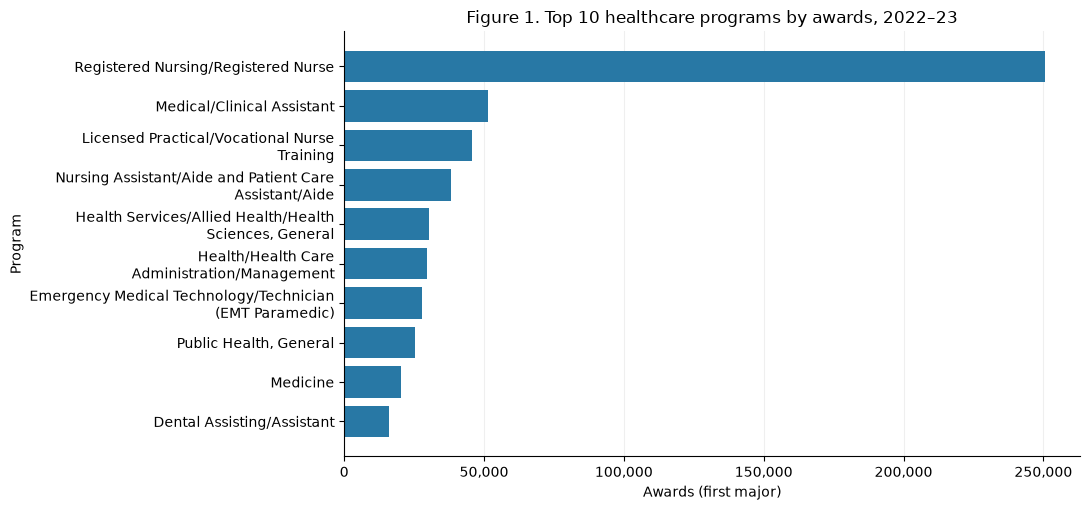

In [7]:
from textwrap import fill
from matplotlib.ticker import StrMethodFormatter


def plot_awards(summary, title, ylabel, top_n=None):
    """Plot ranked award counts with wrapped labels and labeled axes."""
    shown = summary.head(top_n) if top_n else summary
    shown = shown.iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, max(5, 0.52 * len(shown))))
    labels = [fill(str(label), width=43) for label in shown.index]
    ax.barh(labels, shown['awards'], color='#2878A5')
    ax.set(title=title, xlabel='Awards (first major)', ylabel=ylabel)
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.set_axisbelow(True)
    ax.grid(axis='x', alpha=0.2)
    sns.despine(ax=ax)
    fig.tight_layout()
    plt.show()


plot_awards(program_summary, 'Figure 1. Top 10 healthcare programs by awards, 2022–23', 'Program', 10)

In [8]:
print(f"{program_summary.index[0]} leads with {program_summary.iloc[0].awards:,.0f} awards "
      f"({program_summary.iloc[0]['share']:.1%} of the scoped total).")
print('This ranks individual program codes, not combined nursing specialties or unique graduates.')

Registered Nursing/Registered Nurse leads with 250,576 awards (26.3% of the scoped total).
This ranks individual program codes, not combined nursing specialties or unique graduates.


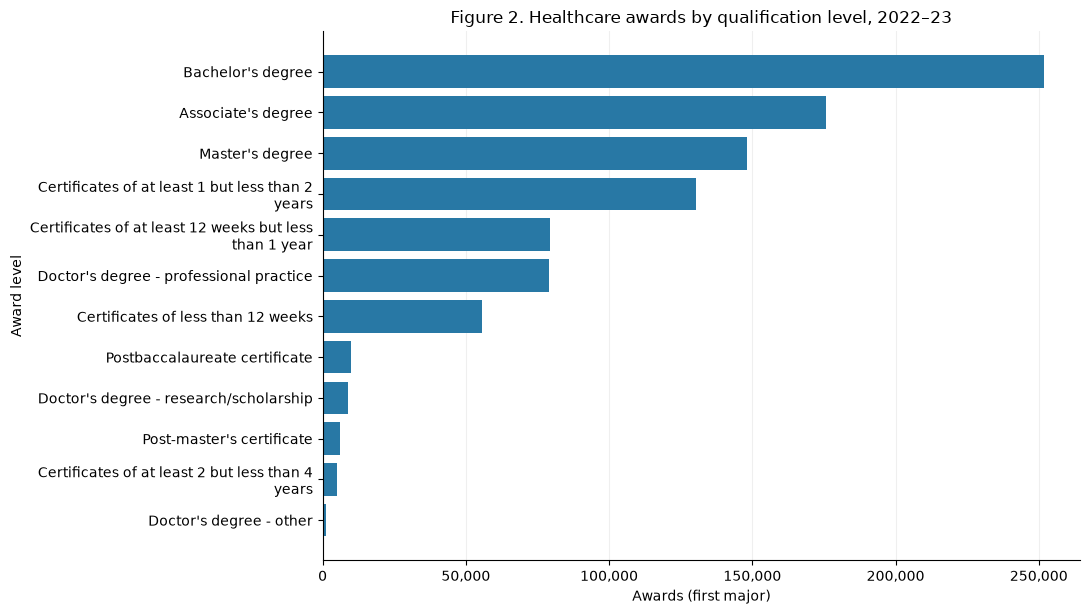

In [9]:
plot_awards(level_summary, 'Figure 2. Healthcare awards by qualification level, 2022–23', 'Award level')

In [10]:
print(f"{level_summary.index[0]} is the largest award category: "
      f"{level_summary.iloc[0].awards:,.0f} awards ({level_summary.iloc[0]['share']:.1%}).")
print('Award levels represent different training pathways; counts do not establish equivalent training length or workforce impact.')

Bachelor's degree is the largest award category: 251,787 awards (26.5%).
Award levels represent different training pathways; counts do not establish equivalent training length or workforce impact.


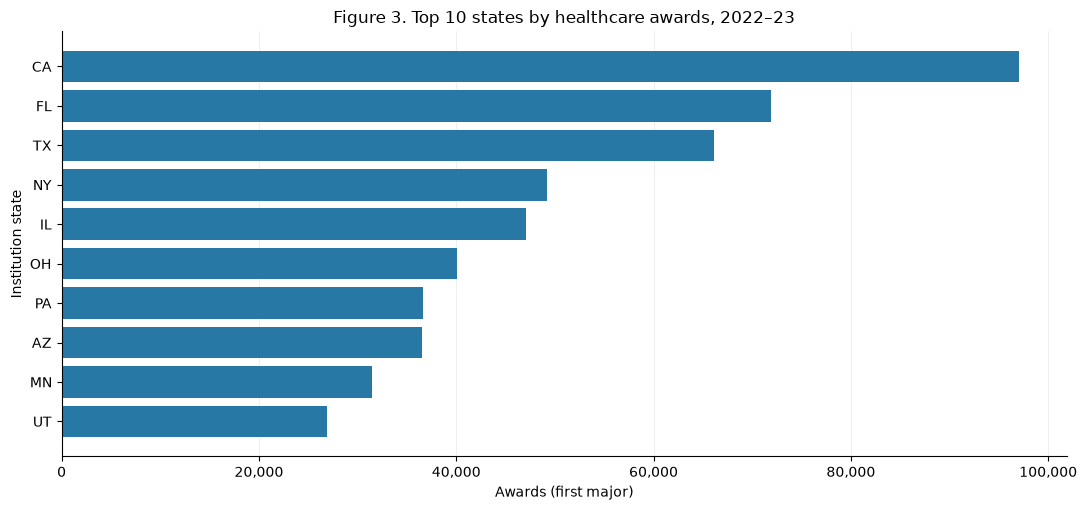

In [11]:
plot_awards(state_summary, 'Figure 3. Top 10 states by healthcare awards, 2022–23', 'Institution state', 10)

In [12]:
print(f"{state_summary.index[0]} has the highest count: {state_summary.iloc[0].awards:,.0f} awards.")
print('These are institution locations, not student residences or future practice locations. Counts are not adjusted for population.')

CA has the highest count: 97,017 awards.
These are institution locations, not student residences or future practice locations. Counts are not adjusted for population.


## Summary

The figures describe the volume and mix of healthcare qualifications, not educational effectiveness. Program, award-level, and state totals reconcile to the same analytical total. The printed interpretations identify the leading categories directly from the calculated results.

The source contains no missing values in the selected fields, and all total-award flags are reported (`R`). Source reporting does not eliminate possible reporting error. Normalizing labels removes dictionary whitespace without altering award counts; restricting major number and geography defines which records are comparable. Excluding territories narrows the population represented, so these results should not be described as covering every institution in the source.

An individual may receive more than one qualification, and awards do not show licensure, learning quality, employment, or workforce entry. A single year cannot establish trends. State comparisons are raw counts and may reflect population, institution size, and online-program reporting locations. The analysis is descriptive and does not establish causal effects.

The separate academic report, scholarly citations, and learner reflections remain for the next stage.